## Задание: классификация MNIST с помощью PyTorch

In [27]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from IPython.display import clear_output

# на всякий случай зафиксируем сид
torch.manual_seed(42)
np.random.seed(42)


In [28]:
# трансформация
mnist_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# выгружаем датасет - train 60к , test 10к
full_train_dataset = datasets.MNIST( root='mnist', train=True,download=True,transform=mnist_transform)

mnist_test_dataset = datasets.MNIST(root='mnist',train=False, download=True,transform=mnist_transform)
# выделяем val выборку
val_size = 10_000
train_size = len(full_train_dataset) - val_size

mnist_train_dataset, mnist_val_dataset = random_split(full_train_dataset,[train_size, val_size],generator=torch.Generator().manual_seed(42))

BATCH_SIZE = 128

train_loader = DataLoader(mnist_train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(mnist_val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(mnist_test_dataset, batch_size=BATCH_SIZE, shuffle=False)
#чек
print(f'train: {len(mnist_train_dataset)}')
print(f'val: {len(mnist_val_dataset)}')
print(f'test: {len(mnist_test_dataset)}')


train: 50000
val: 10000
test: 10000


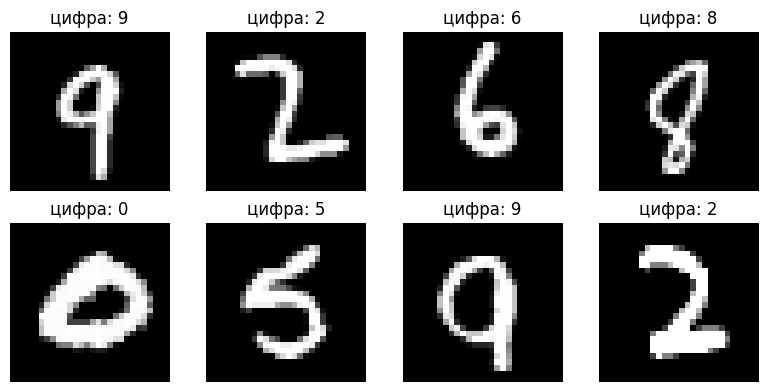

In [29]:
# берём один батч и рисуем несколько картинок
example_images, example_labels = next(iter(train_loader))
plt.figure(figsize=(8, 4))
for idx in range(8):
    plt.subplot(2, 4, idx + 1)
    plt.imshow(example_images[idx].squeeze(0), cmap='gray')
    plt.title(f'цифра: {example_labels[idx].item()}')
    plt.axis('off')

plt.tight_layout()
plt.show()


In [30]:
#простая полносвязная сеть
class SimpleMnistMLP(nn.Module):

    def __init__(self, hidden_units=128):
        super().__init__()
        self.feature_flattener = nn.Flatten()
        self.hidden_layer = nn.Linear(28 * 28, hidden_units)
        self.hidden_activation = nn.ReLU() #активация скрытого слоя
        self.output_layer = nn.Linear(hidden_units, 10)

    def forward(self, input_images):
        flattened = self.feature_flattener(input_images)
        hidden_activations = self.hidden_activation(self.hidden_layer(flattened))
        logits = self.output_layer(hidden_activations)
        return logits

baseline_model = SimpleMnistMLP(hidden_units=128)
print(baseline_model)


SimpleMnistMLP(
  (feature_flattener): Flatten(start_dim=1, end_dim=-1)
  (hidden_layer): Linear(in_features=784, out_features=128, bias=True)
  (hidden_activation): ReLU()
  (output_layer): Linear(in_features=128, out_features=10, bias=True)
)


In [31]:
# посчитаем кол-во обучаемых параметров
total_parameters = sum(param.numel() for param in baseline_model.parameters())
print(f'всего обучаемых параметров в базовой модельке: {total_parameters}')

# чек
example_batch, _ = next(iter(train_loader))
logits_example = baseline_model(example_batch)

print(f'на входе: {example_batch.shape}')
print(f'на выходе: {logits_example.shape}')


всего обучаемых параметров в базовой модельке: 101770
на входе: torch.Size([128, 1, 28, 28])
на выходе: torch.Size([128, 10])


получилось 101770 параметра

почему столько?

в модели 101770 параметров, потому что первый слой соединяет 784 пикселя с 128 нейронами (128 × 784 веса + 128 смещений), а второй слой - 128 нейронов с 10 выходами (10 × 128 весов + 10 смещений)

Это все числа, которые сеть подбирает во время обучения, чтобы научиться распознавать цифры

In [32]:
#у меня cpu, но на всякий случай
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# print(device)
"""
одна эпоха обучения:
1)включаем в train-режим
2)проходимся по всем батчам
3)прямой проход, вычисляем loss, backward и дальше шаг оптимизатора
"""
def train_one_epoch(model, dataloader, loss_function, optimizer, device):
    model.train()
    running_loss = 0.0

    for batch_images, batch_targets in dataloader:
        batch_images = batch_images.to(device)
        batch_targets = batch_targets.to(device)
        optimizer.zero_grad() #обнуляем градиенты
        logits = model(batch_images)
        loss = loss_function(logits, batch_targets) #ошибка модели
        loss.backward() #считаем градиенты
        optimizer.step()
        # умножаем на размер батча, потом усредним по всем объектам
        running_loss += loss.item() * batch_images.size(0)

    return running_loss / len(dataloader.dataset)

"""
оценка средней функции потерь на валидации/тесте
градиенты не считаем, поэтому используем torch.no_grad()
"""
def evaluate_loss(model, dataloader, loss_function, device):

    model.eval()
    running_loss = 0.0
    with torch.no_grad():
        for batch_images, batch_targets in dataloader:
            batch_images = batch_images.to(device)
            batch_targets = batch_targets.to(device)

            logits = model(batch_images)
            loss = loss_function(logits, batch_targets)
            running_loss += loss.item() * batch_images.size(0)

    return running_loss / len(dataloader.dataset)

#тут считаем accuracy, precision, recall и f1
def compute_classification_metrics(model, dataloader, device):

    model.eval()
    all_targets = []
    all_predictions = []
    with torch.no_grad():
        for batch_images, batch_targets in dataloader:
            batch_images = batch_images.to(device)
            logits = model(batch_images)
            predicted = torch.argmax(logits, dim=1).cpu().numpy()
            all_predictions.append(predicted)
            all_targets.append(batch_targets.numpy())

    all_predictions = np.concatenate(all_predictions)
    all_targets = np.concatenate(all_targets)
    accuracy = accuracy_score(all_targets, all_predictions)
    precision = precision_score(all_targets, all_predictions, average='macro', zero_division=0)
    recall = recall_score(all_targets, all_predictions, average='macro', zero_division=0)
    f1 = f1_score(all_targets, all_predictions, average='macro', zero_division=0)

    return accuracy, precision, recall, f1


In [33]:
#после каждой эпохи обновляем график train/val loss
def show_training_curves(history):

    clear_output(wait=True)
    epochs = range(1, len(history['train_loss']) + 1)
    plt.figure(figsize=(10, 4))
    plt.plot(epochs, history['train_loss'], label='Train loss')
    plt.plot(epochs, history['val_loss'],   label='Validation loss')
    plt.xlabel('Эпоха')
    plt.ylabel('Loss')
    plt.yscale('log')
    plt.grid(True)
    plt.legend()
    plt.show()


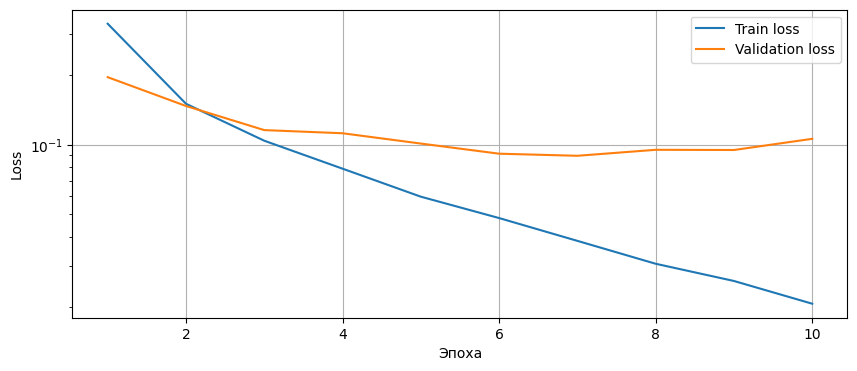

Эпоха 10/10 | train_loss = 0.0206, val_loss = 0.1060
мин ошибка на валидации: 0.08953854728341103
accuracy на тесте: 0.9745
precision: 0.9746652675013008
recall: 0.9741302056804466
f1: 0.9742853705132936


In [34]:
experiment_results = []

NUM_EPOCHS_1 = 10

baseline_model = SimpleMnistMLP(hidden_units=128).to(device)
loss_function_1 = nn.CrossEntropyLoss() #стандартная функция ошибки для классификации
optimizer_1 = torch.optim.Adam(baseline_model.parameters(), lr=1e-3) #оптимизатор изменяет веса

training_history_1 = {'train_loss': [], 'val_loss': []}

for epoch_index in range(NUM_EPOCHS_1):
    train_loss_epoch = train_one_epoch(baseline_model, train_loader, loss_function_1, optimizer_1, device)
    val_loss_epoch = evaluate_loss(baseline_model, val_loader, loss_function_1, device)
    training_history_1['train_loss'].append(train_loss_epoch)
    training_history_1['val_loss'].append(val_loss_epoch)

    show_training_curves(training_history_1)
    #чек
    print(f'Эпоха {epoch_index + 1}/{NUM_EPOCHS_1} | '
          f'train_loss = {train_loss_epoch:.4f}, val_loss = {val_loss_epoch:.4f}')

# мин ошибка на валидации
min_val_loss_1 = min(training_history_1['val_loss'])

# метрики на тесте
acc_1, prec_1, rec_1, f1_1 = compute_classification_metrics(baseline_model, test_loader, device)

experiment_results.append({
    'experiment_id': 'exp_1',
    'description': '1 скрытый слой, без dropout и BatchNorm',
    'min_val_loss': float(min_val_loss_1),
    'test_accuracy': float(acc_1),
    'test_precision': float(prec_1),
    'test_recall': float(rec_1),
    'test_f1': float(f1_1)
})

print('мин ошибка на валидации:', min_val_loss_1)
print('accuracy на тесте:',  acc_1)
print('precision:', prec_1)
print('recall:', rec_1)
print('f1:', f1_1)


In [35]:
class RegularizedMnistMLP(nn.Module):
    """
    более глубокая сеть:
    1)тут несколько скрытых слоёв
    2)после каждого - BatchNorm1d + ReLU + Dropout
    для борьбы с переобучением
    """
    def __init__(self, hidden_units_list=[256, 256, 128], dropout_probability=0.5):
        super().__init__()
        self.feature_flattener = nn.Flatten()

        layers = []
        input_size = 28 * 28

        for hidden_units in hidden_units_list:
            layers.append(nn.Linear(input_size, hidden_units))
            layers.append(nn.BatchNorm1d(hidden_units)) #нормализует выход слоя
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(p=dropout_probability)) #50% нейронов отключаются
            input_size = hidden_units

        # финальный слой в 10 классов
        layers.append(nn.Linear(input_size, 10))
        self.network_body = nn.Sequential(*layers)

    def forward(self, input_images):
        flattened = self.feature_flattener(input_images)
        logits    = self.network_body(flattened)
        return logits


regularized_model = RegularizedMnistMLP().to(device) #на всякий, если будет gpu
print(regularized_model)


RegularizedMnistMLP(
  (feature_flattener): Flatten(start_dim=1, end_dim=-1)
  (network_body): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=256, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.5, inplace=False)
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.5, inplace=False)
    (12): Linear(in_features=128, out_features=10, bias=True)
  )
)


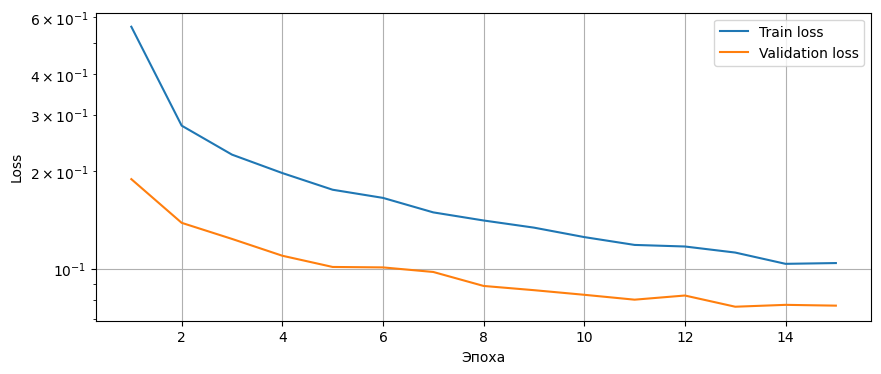

Эпоха 15/15 | train_loss = 0.1042, val_loss = 0.0769
мин ошибка на валидации: 0.07634033444225788
accuracy на тесте: 0.9786
precision: 0.9785381754511311
recall: 0.9785643898692429
f1: 0.9785428020890106


In [36]:
NUM_EPOCHS_2 = 15

loss_function_2 = nn.CrossEntropyLoss()
optimizer_2 = torch.optim.Adam(regularized_model.parameters(), lr=1e-3)

training_history_2 = {'train_loss': [], 'val_loss': []}

for epoch_index in range(NUM_EPOCHS_2):
    train_loss_epoch = train_one_epoch(regularized_model, train_loader, loss_function_2, optimizer_2, device)
    val_loss_epoch = evaluate_loss(regularized_model, val_loader, loss_function_2, device)
    training_history_2['train_loss'].append(train_loss_epoch)
    training_history_2['val_loss'].append(val_loss_epoch)

    show_training_curves(training_history_2)
    #чек
    print(f'Эпоха {epoch_index + 1}/{NUM_EPOCHS_2} | '
          f'train_loss = {train_loss_epoch:.4f}, val_loss = {val_loss_epoch:.4f}')

min_val_loss_2 = min(training_history_2['val_loss'])
acc_2, prec_2, rec_2, f1_2 = compute_classification_metrics(regularized_model, test_loader, device)

experiment_results.append({
    'experiment_id': 'exp_2_regularized_mlp',
    'description': '3 скрытых слоя, ReLU, BatchNorm, Dropout=0.5',
    'min_val_loss': float(min_val_loss_2),
    'test_accuracy': float(acc_2),
    'test_precision': float(prec_2),
    'test_recall': float(rec_2),
    'test_f1': float(f1_2)
})

print('мин ошибка на валидации:', min_val_loss_2)
print('accuracy на тесте:', acc_2)
print('precision:', prec_2)
print('recall:', rec_2)
print('f1:', f1_2)


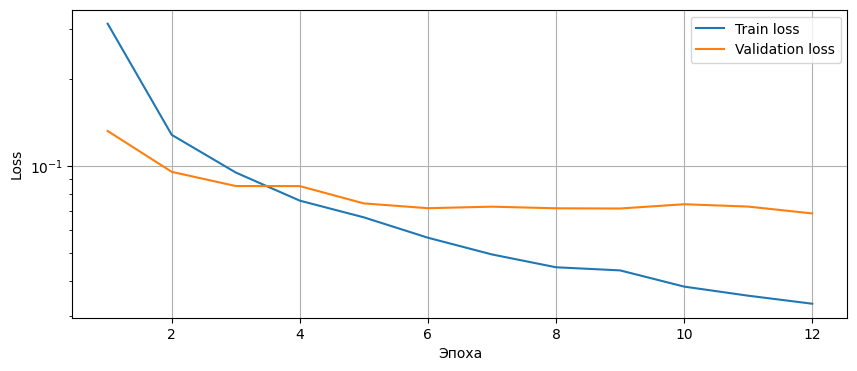

Эпоха 12/12 | train_loss = 0.0332, val_loss = 0.0684
мин ошибка на валидации: 0.06844452998898923
accuracy на тесте: 0.9818
precision: 0.9817658103928502
recall: 0.9816538504349477
f1: 0.9816949409577651


In [37]:
model_variant_3 = RegularizedMnistMLP(
    hidden_units_list=[256, 128],  # чуть менее глубокая сеть
    dropout_probability=0.2        # мягче регуляризация
).to(device)

NUM_EPOCHS_3   = 12
loss_function_3 = nn.CrossEntropyLoss()
optimizer_3 = torch.optim.Adam(model_variant_3.parameters(), lr=1e-3)

training_history_3 = {'train_loss': [], 'val_loss': []}

for epoch_index in range(NUM_EPOCHS_3):
    train_loss_epoch = train_one_epoch(model_variant_3, train_loader, loss_function_3, optimizer_3, device)
    val_loss_epoch = evaluate_loss(model_variant_3, val_loader, loss_function_3, device)
    training_history_3['train_loss'].append(train_loss_epoch)
    training_history_3['val_loss'].append(val_loss_epoch)

    show_training_curves(training_history_3)
    #чек
    print(f'Эпоха {epoch_index + 1}/{NUM_EPOCHS_3} | '
          f'train_loss = {train_loss_epoch:.4f}, val_loss = {val_loss_epoch:.4f}')

min_val_loss_3 = min(training_history_3['val_loss'])
acc_3, prec_3, rec_3, f1_3 = compute_classification_metrics(model_variant_3, test_loader, device)

experiment_results.append({
    'experiment_id': 'exp_3_compact_mlp',
    'description': '2 скрытых слоя, ReLU, BatchNorm, Dropout=0.2',
    'min_val_loss': float(min_val_loss_3),
    'test_accuracy': float(acc_3),
    'test_precision': float(prec_3),
    'test_recall': float(rec_3),
    'test_f1': float(f1_3)
})

print('мин ошибка на валидации:', min_val_loss_3)
print('accuracy на тесте:', acc_3)
print('precision:', prec_3)
print('recall:', rec_3)
print('f1:', f1_3)


In [38]:
#итоговая табличка с описаниями и результатами
results_table = pd.DataFrame(experiment_results)
results_table


,experiment_id,description,min_val_loss,test_accuracy,test_precision,test_recall,test_f1
0,exp_1,"1 скрытый слой, без dropout и BatchNorm",0.089539,0.9745,0.974665,0.974130,0.974285
1,exp_2_regularized_mlp,"3 скрытых слоя, ReLU, BatchNorm, Dropout=0.5",0.076340,0.9786,0.978538,0.978564,0.978543
2,exp_3_compact_mlp,"2 скрытых слоя, ReLU, BatchNorm, Dropout=0.2",0.068445,0.9818,0.981766,0.981654,0.981695


### Выводы по экспериментам

1. **Эксперимент 1 (базовая моделька)**  
   Простая сеть с одним скрытым слоем и без регуляризации довольно быстро обучается и достигает, в целом, неплохого качества, судя по метрикам
   По графикам видно, что train loss снижается, но val loss после некоторого момента начинает колебаться, что говорит о начале переобучения

2. **Эксперимент 2 (глубокая моделька с BatchNorm и Dropout=0.5)**  
   Здесь мы добавляем несколько скрытых слоёв, а после каждого слоя используем BatchNorm и Dropout (для регуляризации)
   BatchNorm стабилизирует распределение активаций, dropout случайно "отключает" часть нейронов и тем самым не даёт модели выучить шум в обучающей выборке
   По итогу: мин ошибка на валидации стала ниже, а метрики на тесте (accuracy, precision, recall, f1) улучшились относительно базовой модели

3. **Эксперимент 3 (моделька попроще, Dropout=0.2)**  
   В третьем варианте уменьшаем глубину сети и ослабили регуляризацию (поставили Dropout поменьше)

   Такая модель быстрее сходится и лучше подстраивается под train, но тут сложнее контролировать переобучение  
   Но на тестовой выборке её качество внезапно оказалось лучше, чем у более глубокой и сильнее регуляризованной (где dropout побольше) модели из 2 эксперимента



**Итог:**

Из итоговой таблицы с метриками видно, что лучше всего себя показала модель из 3 эксперимента - у неё самые высокие значения accuracy, precision, recall и f1
Она имеет два скрытых слоя и использует BatchNorm и Dropout с меньшим коэффициентом (0.2)
Вероятно, такая архитектура оказалась наиболее удачной, потому что модель достаточно сложная, чтобы распознавать различные особенности написания цифр, но при этом не слишком глубокая
Это связано с тем, что в этой модели несколько скрытых слоёв, поэтому она может лучше распознавать разные особенности написания цифр
При этом используются более умеренный Dropout, который помогает пофиксить переобучение

В итоге моделька получается достаточно сложной, чтобы хорошо учиться, но при этом не запоминает данные слишком сильно, поэтому лучше работает на тестовой выборке по сравнению 1 и 2  моделями